# Кластеризация

In [1]:
from sklearn.datasets import make_classification, make_blobs
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

## Генерация данных

In [2]:
data_mc, data_y_mc = make_classification(
    n_samples=250,
    n_classes=4, 
    n_features=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    flip_y=0,
    random_state=45)

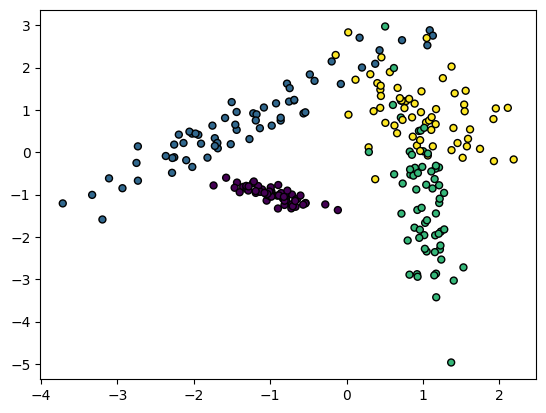

In [3]:
plt.scatter(data_mc[:, 0], data_mc[:, 1], marker="o", c=data_y_mc, s=25, edgecolor="k")
plt.show()

In [4]:
data_mb, data_y_mb = make_blobs(
    n_samples=250, 
    random_state=7)

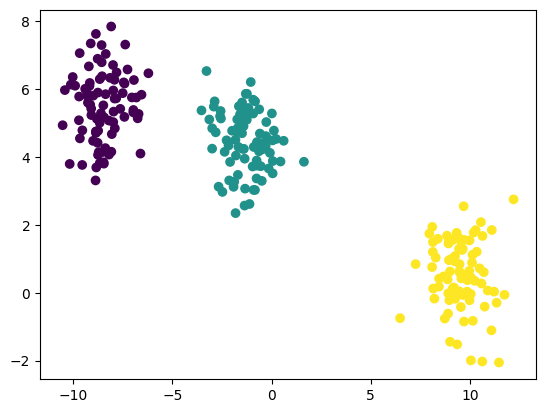

In [5]:
plt.scatter(data_mb[:, 0], data_mb[:, 1], c=data_y_mb, marker="o")

In [6]:
data = pd.read_csv('../data/processed_smoke_detector.csv')
print(data.head())
data_cl = data.drop('Fire Alarm', axis=1)
data_y_cl = data['Fire Alarm']

   Temperature[C]  Humidity[%]  TVOC[ppb]  eCO2[ppm]   Raw H2  Raw Ethanol  \
0          27.041        49.80       19.0      400.0  13059.0        19951   
1          26.987        54.26        1.0      400.0  13078.0        19975   
2          26.985        53.66       10.0      400.0  13068.0        19955   
3          26.983        53.07       10.0      400.0  13069.0        19963   
4          26.982        52.57       13.0      400.0  13072.0        19958   

   Pressure[hPa]  NC2.5  Fire Alarm  IsItDay?  Weekday_0  Weekday_1  Weekday_2  
0        939.777  0.011           0         0          0          0          1  
1        939.765  0.011           0         0          0          0          1  
2        939.768  0.011           0         0          0          0          1  
3        939.775  0.013           0         0          0          0          1  
4        939.770  0.013           0         0          0          0          1  


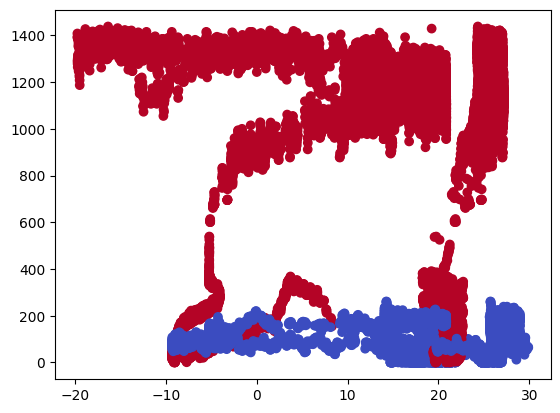

In [7]:
plt.scatter(data_cl.values[:, 0], data_cl.values[:, 2], c=data_y_cl, marker="o", cmap='coolwarm')

In [8]:
from mpl_toolkits.mplot3d import Axes3D

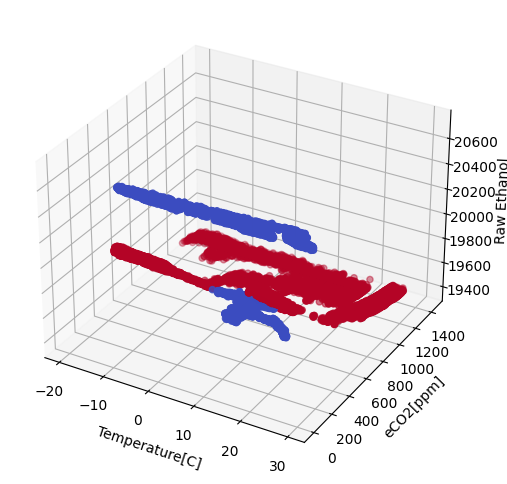

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')  # Создаем 3D оси

ax.set_xlabel('Temperature[C]')
ax.set_ylabel('eCO2[ppm]')
ax.set_zlabel('Raw Ethanol')
# Предполагаем, что данные находятся в определенных столбцах
ax.scatter(data_cl.iloc[:, 0], data_cl.iloc[:, 2], data_cl.iloc[:, 5], c=data_y_cl, cmap='coolwarm')

plt.show()

## Кластеризация сгенерированных данных

In [10]:
from sklearn.metrics.cluster import rand_score
from sklearn.metrics import silhouette_score

In [11]:
scal_data_mc = StandardScaler().fit_transform(data_mc)
scal_data_mb = StandardScaler().fit_transform(data_mb)
scal_data_cl = StandardScaler().fit_transform(data_cl)

### K-means

In [12]:
from sklearn.cluster import KMeans

In [13]:
wcss_lst = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scal_data_mc)
    wcss_lst.append(kmeans.inertia_)

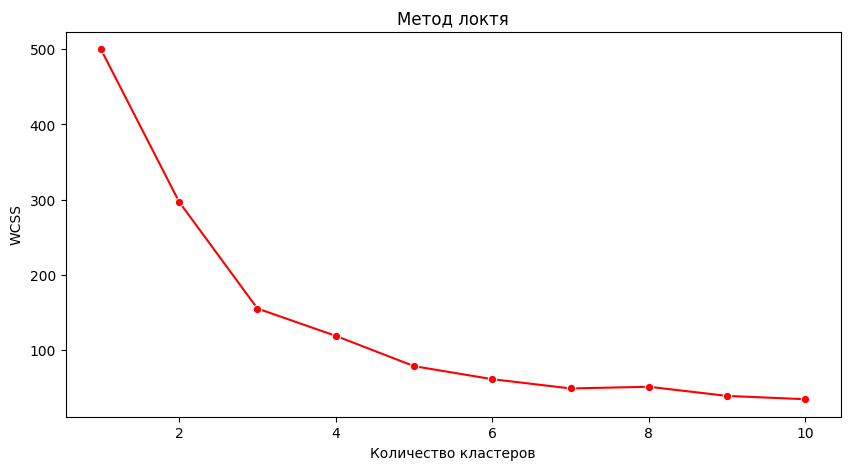

In [14]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, 11), y=wcss_lst, marker='o', color='red')
plt.title("Метод локтя")
plt.xlabel("Количество кластеров")
plt.ylabel("WCSS")
plt.show()

In [15]:
kl = KneeLocator(range(1, 11), wcss_lst, curve='convex', direction='decreasing')
kl.elbow

3

In [16]:
kmeans_mc = KMeans(n_clusters=kl.elbow, random_state=4)
labels_mc = kmeans_mc.fit_predict(scal_data_mc)

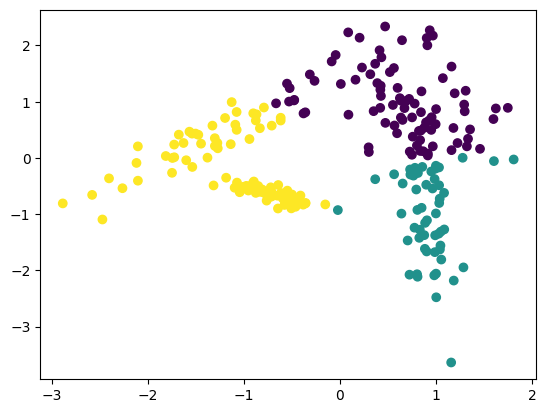

In [17]:
plt.scatter(scal_data_mc[:,0], scal_data_mc[:,1], c=labels_mc)

In [18]:
print("Внешняя метрика (rand score)", rand_score(labels_mc, data_y_mc))
print("Внутренняя метрика (силуэт): ", silhouette_score(scal_data_mc, labels_mc))

Внешняя метрика (rand score) 0.7824899598393574
Внутренняя метрика (силуэт):  0.4941258089588965


In [19]:
wcss_lst = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scal_data_mb)
    wcss_lst.append(kmeans.inertia_)

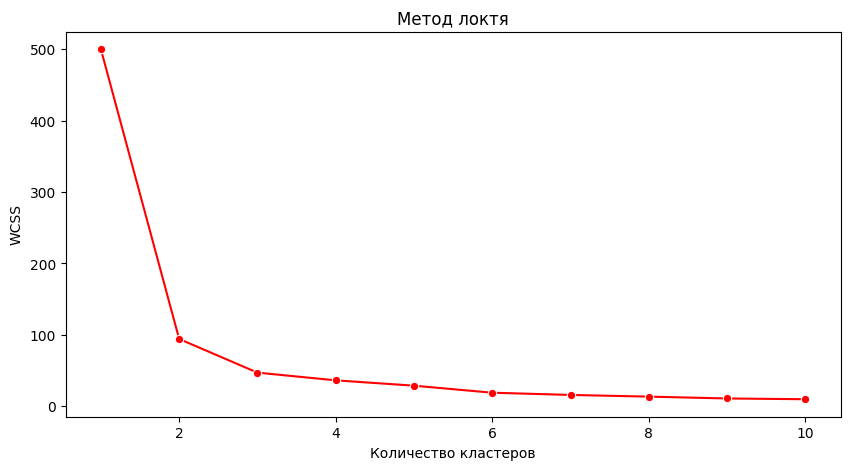

In [20]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, 11), y=wcss_lst, marker='o', color='red')
plt.title("Метод локтя")
plt.xlabel("Количество кластеров")
plt.ylabel("WCSS")
plt.show()

In [21]:
kl = KneeLocator(range(1, 11), wcss_lst, curve='convex', direction='decreasing')
kl.elbow

2

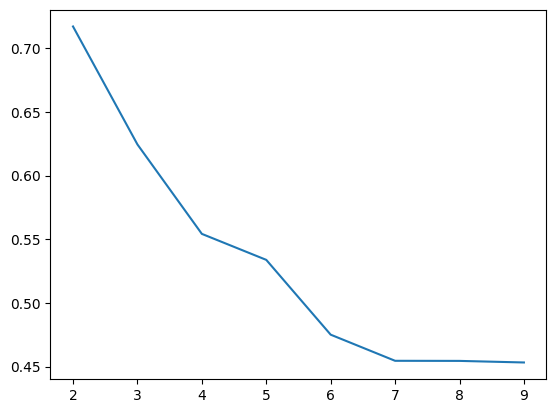

In [22]:
from sklearn.metrics import silhouette_score

ss = []

for i in range(2, 10):
  ss.append(silhouette_score(scal_data_mb, KMeans(i, n_init='auto').fit(scal_data_mb).labels_))

plt.plot(range(2,10), ss)

In [23]:
# kmeans_mb = KMeans(n_clusters=kl.elbow, random_state=4)
kmeans_mb = KMeans(n_clusters=3, random_state=4)
labels_mb = kmeans_mb.fit_predict(scal_data_mb)

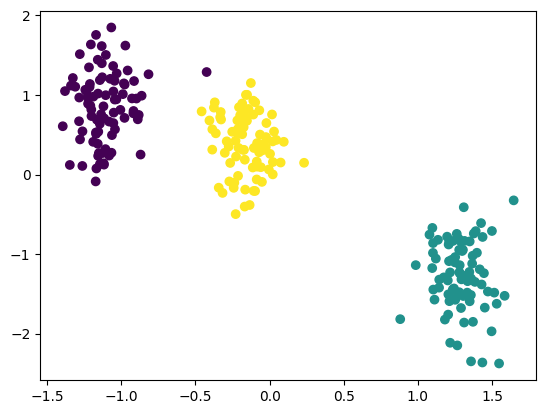

In [24]:
plt.scatter(scal_data_mb[:,0], scal_data_mb[:,1], c=labels_mb)

In [25]:
print("Внешняя метрика (rand score)", rand_score(labels_mb, data_y_mb))
print("Внутренняя метрика (силуэт): ", silhouette_score(scal_data_mb, labels_mb))

Внешняя метрика (rand score) 0.9946666666666667
Внутренняя метрика (силуэт):  0.6244964228718612


### Иерархическая кластеризация

In [26]:
from scipy.cluster.hierarchy import linkage, fcluster

In [27]:
clusters_mc = linkage(scal_data_mc, method="ward")
labels = fcluster(clusters_mc, t=4, criterion='maxclust')

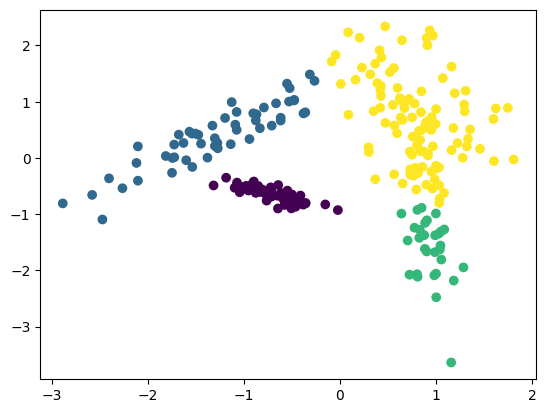

In [28]:
plt.scatter(scal_data_mc[:, 0], scal_data_mc[:, 1], c=labels)
plt.show()

In [29]:
print("Внешняя метрика (rand score):", rand_score(labels, data_y_mc))
print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_mc, labels))

Внешняя метрика (rand score): 0.8581847389558233
Внутренняя метрика (силуэт): 0.5038371010351196


In [30]:
clusters_mb = linkage(scal_data_mb, method="ward")
labels = fcluster(clusters_mb, t=3, criterion='maxclust')

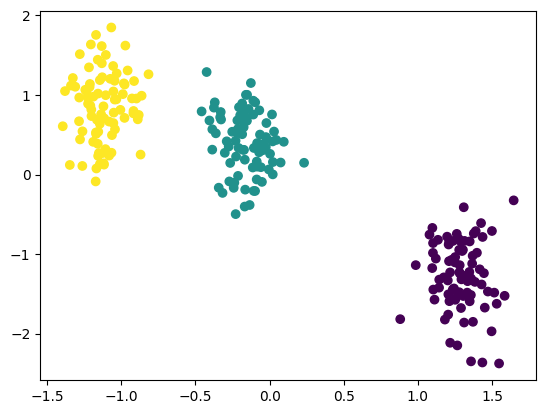

In [31]:
plt.scatter(scal_data_mb[:, 0], scal_data_mb[:, 1], c=labels)
plt.show()

In [32]:
print("Внешняя метрика (rand score):", rand_score(labels, data_y_mb))
print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_mb, labels))

Внешняя метрика (rand score): 1.0
Внутренняя метрика (силуэт): 0.6242843092815558


### DBSCAN

In [33]:
from sklearn.cluster import DBSCAN
import numpy as np

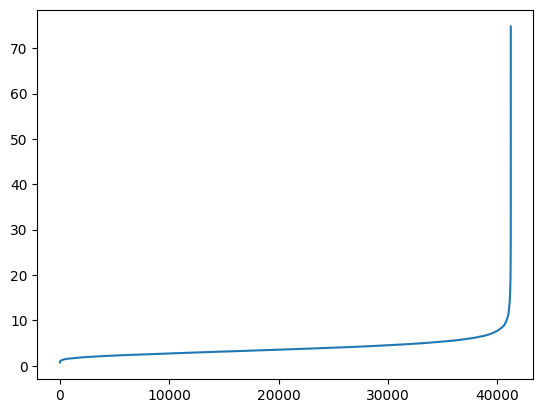

In [34]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=4).fit(data)
distances, indices = nbrs.kneighbors(data)
distances = np.mean(distances, axis=1)
distances = np.sort(distances)
plt.plot(distances)

In [35]:
eps_values = np.linspace(0.1, 2.0, 20)  # диапазон для eps
min_samples_values = range(2, 10)       # диапазон для min_samples

best_score = -1
best_params = {'eps': None, 'min_samples': None}

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(scal_data_mc)
        labels = db.labels_
        
        if len(np.unique(labels)) > 1 and (labels != -1).any():
            valid_labels = labels[labels != -1]
            valid_data = scal_data_mc[labels != -1]
            
            if len(np.unique(valid_labels)) >= 2:
                score = silhouette_score(valid_data, valid_labels)
                
                if score > best_score:
                    best_score = score
                    best_params['eps'] = eps
                    best_params['min_samples'] = min_samples

In [36]:
dbscan = DBSCAN(
    eps=best_params['eps'], 
    min_samples=best_params['min_samples']
).fit(scal_data_mc)

labels = dbscan.labels_

[-1  0  1  2]


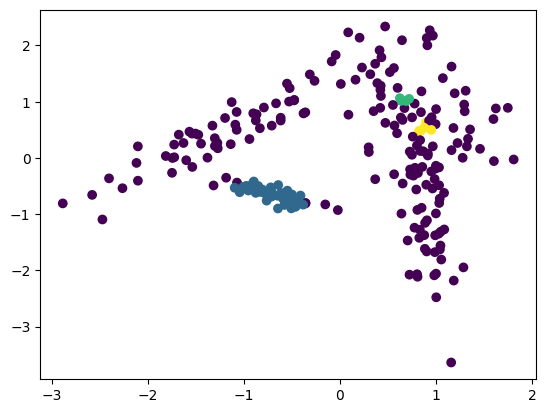

In [37]:
print(np.unique(dbscan.labels_))
plt.scatter(scal_data_mc[:,0], scal_data_mc[:,1], c=dbscan.labels_)

In [38]:
print("Внешняя метрика (rand score):", rand_score(labels, data_y_mc))
print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_mc, labels))

Внешняя метрика (rand score): 0.5940240963855422
Внутренняя метрика (силуэт): -0.11997230993680978


In [ ]:
eps_values = np.linspace(0.1, 2.0, 20)  # диапазон для eps
min_samples_values = range(2, 10)       # диапазон для min_samples

best_score = -1
best_params = {'eps': None, 'min_samples': None}

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_samples).fit(scal_data_mb)
        labels = db.labels_
        
        if len(np.unique(labels)) > 1 and (labels != -1).any():
            valid_labels = labels[labels != -1]
            valid_data = scal_data_mb[labels != -1]
            
            if len(np.unique(valid_labels)) >= 2:
                score = silhouette_score(valid_data, valid_labels)

                if score > best_score:
                    best_score = score
                    best_params['eps'] = eps
                    best_params['min_samples'] = min_samples

In [40]:
dbscan = DBSCAN(
    eps=best_params['eps'], 
    min_samples=best_params['min_samples']
).fit(scal_data_mb)

labels = dbscan.labels_

[0 1]


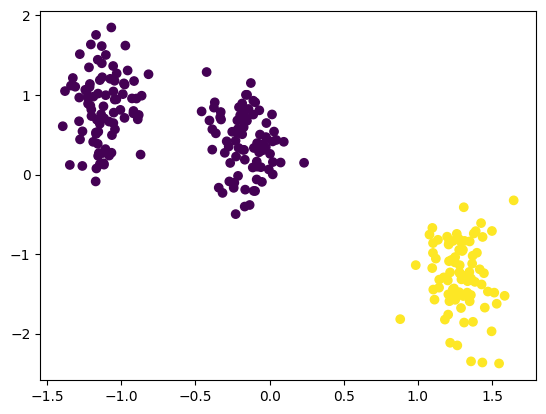

In [41]:
print(np.unique(dbscan.labels_))
plt.scatter(scal_data_mb[:,0], scal_data_mb[:,1], c=dbscan.labels_)

In [42]:
print("Внешняя метрика (rand score):", rand_score(labels, data_y_mb))
print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_mb, labels))

Внешняя метрика (rand score): 0.776
Внутренняя метрика (силуэт): 0.7171756639679733


### EM-алгоритм

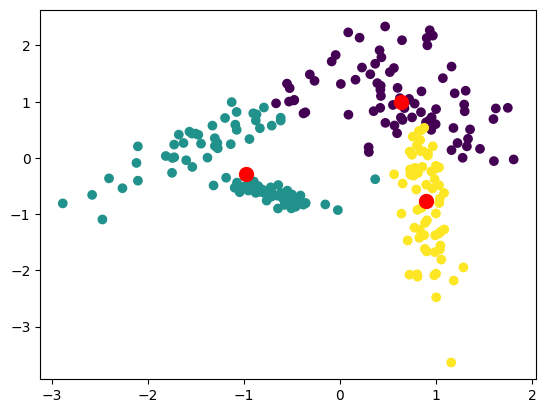

In [43]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3).fit(scal_data_mc)

labels = gm.predict(scal_data_mc)

plt.scatter(scal_data_mc[:,0], scal_data_mc[:,1], c=labels)
plt.scatter(gm.means_[:,0], gm.means_[:,1], s=100, c='red')

In [44]:
print("Внешняя метрика (rand score):", rand_score(labels, data_y_mc))
print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_mc, labels))

Внешняя метрика (rand score): 0.8018313253012048
Внутренняя метрика (силуэт): 0.45591721510923316


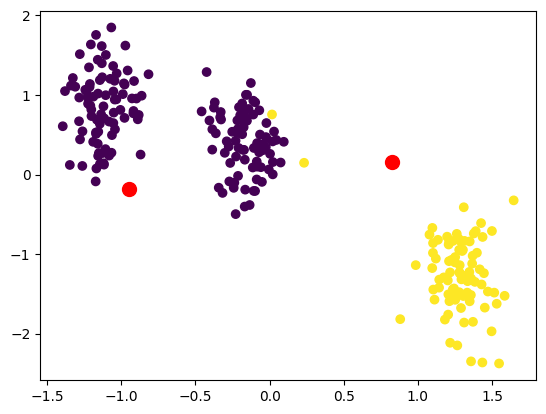

In [45]:
gm = GaussianMixture(n_components=2).fit(scal_data_mc)

labels = gm.predict(scal_data_mb)

plt.scatter(scal_data_mb[:,0], scal_data_mb[:,1], c=labels)
plt.scatter(gm.means_[:,0], gm.means_[:,1], s=100, c='red')

In [46]:
print("Внешняя метрика (rand score):", rand_score(labels, data_y_mb))
print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_mb, labels))

Внешняя метрика (rand score): 0.770859437751004
Внутренняя метрика (силуэт): 0.7013917232736196


### Affinity Propagation

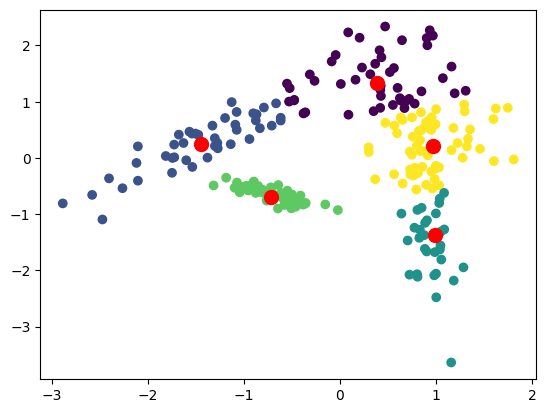

In [47]:
from sklearn.cluster import AffinityPropagation

clusters_mc = AffinityPropagation(preference=-42, damping=0.9).fit(scal_data_mc)

plt.scatter(scal_data_mc[:,0], scal_data_mc[:,1], c=clusters_mc.labels_)
plt.scatter(clusters_mc.cluster_centers_[:,0], clusters_mc.cluster_centers_[:,1], s=100, c='red')

In [48]:
print("Внешняя метрика (rand score):", rand_score(clusters_mc.labels_, data_y_mc))
print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_mc, clusters_mc.labels_))

Внешняя метрика (rand score): 0.8593734939759036
Внутренняя метрика (силуэт): 0.5131546498909226


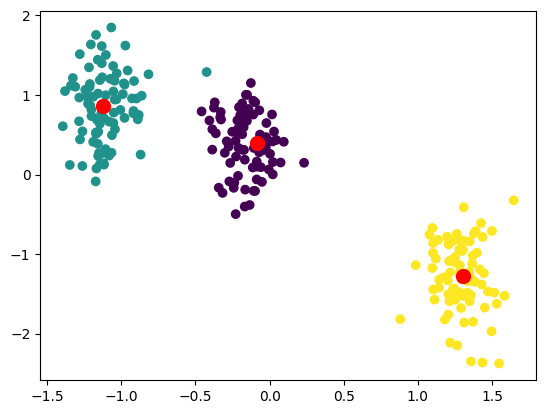

In [49]:
clusters_mb = AffinityPropagation(preference=-42, damping=0.9).fit(scal_data_mb)

plt.scatter(scal_data_mb[:,0], scal_data_mb[:,1], c=clusters_mb.labels_)
plt.scatter(clusters_mb.cluster_centers_[:,0], clusters_mb.cluster_centers_[:,1], s=100, c='red')

In [50]:
print("Внешняя метрика (rand score):", rand_score(clusters_mb.labels_, data_y_mb))
print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_mb, clusters_mb.labels_))

Внешняя метрика (rand score): 0.9946666666666667
Внутренняя метрика (силуэт): 0.6244964228718612


## Кластеризация на данных классификации

In [51]:
scal_data_cl
data_y_cl

0        0
1        0
2        0
3        0
4        0
        ..
41242    0
41243    0
41244    0
41245    0
41246    0
Name: Fire Alarm, Length: 41247, dtype: int64

### K-means

In [52]:
wcss_lst = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scal_data_cl)
    wcss_lst.append(kmeans.inertia_)

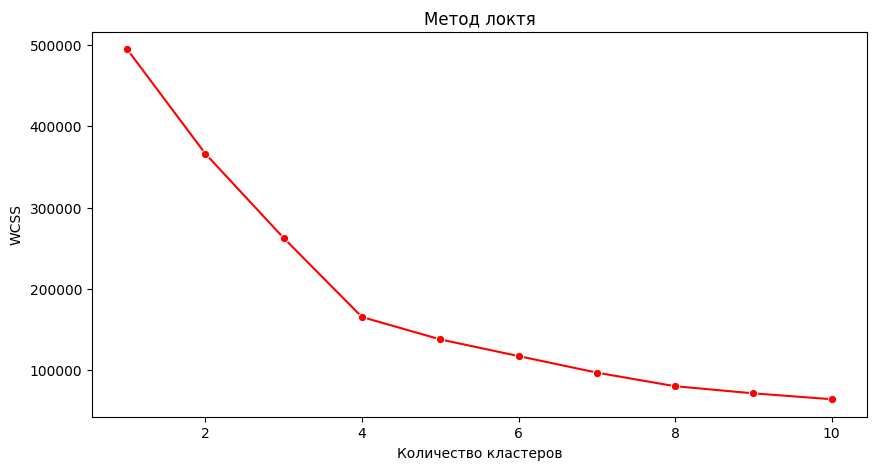

In [53]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=range(1, 11), y=wcss_lst, marker='o', color='red')
plt.title("Метод локтя")
plt.xlabel("Количество кластеров")
plt.ylabel("WCSS")
plt.show()

In [54]:
kl = KneeLocator(range(1, 11), wcss_lst, curve='convex', direction='decreasing')
kl.elbow

4

In [55]:
kmeans_cl = KMeans(n_clusters=kl.elbow, random_state=4)
labels_cl = kmeans_mc.fit_predict(scal_data_cl)

In [56]:
print("Внешняя метрика (rand score):", rand_score(labels_cl, data_y_cl))
print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_cl, labels_cl))

Внешняя метрика (rand score): 0.8291871193861391
Внутренняя метрика (силуэт): 0.515617759902936


### DBSCAN

In [ ]:
eps_values = np.linspace(0.1, 2.0, 20)  # диапазон для eps
min_samples_values = range(2, 10)       # диапазон для min_samples

best_score = -1
best_params = {'eps': None, 'min_samples': None}

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(scal_data_cl)
        labels = db.labels_
        
        if len(np.unique(labels)) > 1 and (labels != -1).any():
            valid_labels = labels[labels != -1]
            valid_data = scal_data_cl[labels != -1]
            
            if len(np.unique(valid_labels)) >= 2:
                score = silhouette_score(valid_data, valid_labels)
                
                if score > best_score:
                    best_score = score
                    best_params['eps'] = eps
                    best_params['min_samples'] = min_samples

In [58]:
dbscan = DBSCAN(
    eps=0.1, 
    min_samples=4
).fit(scal_data_cl)

labels = dbscan.labels_

In [59]:
print("Внешняя метрика (rand score):", rand_score(labels_cl, data_y_cl))
print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_cl, labels_cl))

Внешняя метрика (rand score): 0.8291871193861391
Внутренняя метрика (силуэт): 0.515617759902936


### EM-алгоритм


In [63]:
gm = GaussianMixture(n_components=4).fit(scal_data_cl)
labels = gm.predict(scal_data_cl)

In [ ]:
print("Внешняя метрика (rand score):", rand_score(labels.all, scal_data_cl))

In [ ]:

print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_cl , labels))

Внутренняя метрика (силуэт): 0.47587671518577596


### Affinity Propagation

In [79]:
data = pd.read_csv('../data/processed_smoke_detector.csv')
data = data.sample(10000)
data_cl = data.drop('Fire Alarm', axis=1)
data_y_cl = data['Fire Alarm']
scal_data_cl = StandardScaler().fit_transform(data_cl)

In [80]:
af = AffinityPropagation()
clusters_cl = af.fit(scal_data_cl)

In [81]:
print("Внешняя метрика (rand score):", rand_score(clusters_cl.labels_, data_y_cl))
print("Внутренняя метрика (силуэт):", silhouette_score(scal_data_cl, clusters_cl.labels_))

Внешняя метрика (rand score): 0.3551571357135714
Внутренняя метрика (силуэт): 0.2749172639211216


## Добавление столбца кластеризации в датасет классификации